# Battery cascade time-explicit LCA (1st-life EV → 2nd-life stationary → recycling)

This notebook extends the [fleet-level EV example](./example_electric_vehicle_fleet.ipynb)
from a single product system (vehicles entering and leaving the stock) to a
**cascading product system** in which retired EV battery packs are partly
redeployed for stationary grid service, then eventually recycled back into the
material supply chain. We model

1. an exogenous EV stock trajectory with a Weibull lifetime (1st life),
2. a fraction $\alpha(t)$ of retired packs that enter a stationary 2nd life,
   itself with its own Weibull lifetime,
3. recycling at the end of both the 1st and 2nd lives, with a recovery
   efficiency $\eta(t)$ that ramps up over time.

All three flows are coupled in [flodym](https://github.com/pik-piam/flodym):
the EV outflow drives the 2nd-life inflow, the 2nd-life outflow drives part of
the recycling throughput, and the recycling throughput times $\eta(t)$ gives
the avoided-virgin-battery credit.

We then plug each of these time series into `bw_timex` as
`TemporalDistribution`s on the corresponding fleet-level exchanges and compare
two scenarios:

- **Linear**: every retired pack goes straight to disposal — same as the fleet
  notebook.
- **Cascade**: $\alpha(t)$ ramps from 5% in 2025 to 55% in 2050, $\eta(t)$ from
  50% to 95%, and a closed-loop recycling credit subtracts the corresponding
  avoided virgin battery production.

> **Note:** as in the fleet notebook, this example uses tiny made-up
> backgrounds for 2020 / 2030 / 2040 so it is fully reproducible. Real cell
> chemistries (NMC, LFP, …) and real recycling inventories would replace the
> single `battery` and `battery_eol` processes in a research application.

## Background databases

We reuse exactly the same toy biosphere and three time-stamped backgrounds as
in the fleet notebook, so that the two examples are directly comparable.

In [1]:
import bw2data as bd

bd.projects.set_current("battery_cascade")

/usr/local/lib/python3.11/dist-packages/bw2calc/__init__.py:56: UserWarning: 
It seems like you have an AMD/INTEL x64 architecture, but haven't installed pypardiso:

    https://pypi.org/project/pypardiso/

Installing it could give you much faster calculations.

  warnings.warn(PYPARDISO_WARNING)


In [2]:
for db in list(bd.databases):
    del bd.databases[db]

In [3]:
biosphere = bd.Database("biosphere")
biosphere.register()
biosphere.write(
    {
        ("biosphere", "CO2"): {
            "type": "emission",
            "name": "carbon dioxide",
        },
    }
)

background_2020 = bd.Database("background_2020"); background_2020.register(); background_2020.write({})
background_2030 = bd.Database("background_2030"); background_2030.register(); background_2030.write({})
background_2040 = bd.Database("background_2040"); background_2040.register(); background_2040.write({})

background_databases = [background_2020, background_2030, background_2040]

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 10782.27it/s]

15:27:22+0000 [info     ] Vacuuming database            


In [4]:
process_co2_emissions = {
    "glider":         (10,   5,    2.5),    # kg CO2 / kg
    "powertrain":     (20,   10,   7.5),
    "battery":        (10,   5,    4),
    "electricity":    (0.5,  0.25, 0.075),  # kg CO2 / kWh
    "glider_eol":     (0.01, 0.0075, 0.005),
    "powertrain_eol": (0.01, 0.0075, 0.005),
    "battery_eol":    (1,    0.5,  0.25),
}

node_co2 = biosphere.get("CO2")

for component_name, gwis in process_co2_emissions.items():
    for database, gwi in zip(background_databases, gwis):
        database.new_node(component_name, name=component_name, location="somewhere").save()
        component = database.get(component_name)
        component["reference product"] = component_name
        component.save()
        production_amount = -1 if "eol" in component_name else 1
        component.new_edge(input=component, amount=production_amount, type="production").save()
        component.new_edge(input=node_co2, amount=gwi, type="biosphere").save()

## Per-vehicle and cascade parameters

The vehicle-level assumptions are unchanged from the fleet notebook. The new
parameters describe the cascade itself:

- $\alpha(t)$ — share of retired EV packs that enter a 2nd life. We let it
  ramp from 5% in 2025 to 55% in 2050.
- $\eta(t)$ — battery recycling recovery efficiency, ramped from 50% in 2025
  to 95% in 2050 (matching the EU Battery Regulation Art. 73 minima for Li/Ni).
- 2nd-life Weibull lifetime: shape $k=4$, scale $\lambda=8$ years
  (mean ≈ 7 years residual life on top of vehicle life).
- A small electricity input per pack repurposing (testing & reassembly).
- A round-trip + auxiliary loss fraction on the electricity throughput of
  each 2nd-life pack-year, charged to the cascade.

In [5]:
ELECTRICITY_CONSUMPTION = 0.2      # kWh / km
MILEAGE = 150_000                  # km, per-vehicle lifetime mileage

MASS_GLIDER     = 840              # kg
MASS_POWERTRAIN = 80
MASS_BATTERY    = 280              # kg per pack — also the per-pack recyclable mass

# --- Cascade parameters ---
ALPHA_2025 = 0.05    # share of EV outflow entering 2nd life today
ALPHA_2050 = 0.55    # cascade target
ETA_2025   = 0.50    # battery recovery efficiency today
ETA_2050   = 0.95    # extrapolated EU Reg minimum

SL_WEIBULL_SHAPE = 4.0
SL_WEIBULL_SCALE = 8.0     # years residual stationary life

# Per pack repurposing: small electricity input (testing & reassembly)
PACK_REPURPOSING_KWH_PER_KG = 0.5

# Per pack-year stationary operation: electricity charged for round-trip + aux losses
PACK_NOMINAL_KWH = 60                                      # kWh installed per pack
ANNUAL_CYCLES_TIMES_DOD = 200                              # equivalent full cycles × DOD
LOSS_FRACTION = 0.10                                       # round-trip + auxiliary

## Coupled dynamic MFA in flodym

Three coupled stocks, all annual on `[2015, 2055]`:

| Stock | Driver | Inflow | Outflow | Lifetime |
|------|------|------|------|------|
| EV pack in vehicle | exogenous EV stock | new packs | retiring packs | Weibull (vehicle) |
| 2nd-life pack | $\alpha(t)\,\cdot$ EV outflow | repurposed packs | 2nd EoL | Weibull (stationary) |
| Recycling throughput | EV direct + 2nd-life outflow | retiring packs | recovered metals | flow only |

The recovered material is `recycling × η(t)` and acts as a substitution credit
on the foreground LCA model (avoided virgin battery production).

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from flodym import (
    Dimension,
    DimensionSet,
    StockArray,
    StockDrivenDSM,
    InflowDrivenDSM,
    WeibullLifetime,
)

In [7]:
YEAR_START = 2015
YEAR_END   = 2055
years = np.arange(YEAR_START, YEAR_END + 1)

time_dim = Dimension(name="Time", letter="t", items=years.tolist(), dtype=int)
dims = DimensionSet(dim_list=[time_dim])

### EV stock and 1st-life dynamics

Same stock-driven model and Weibull lifetime as in the fleet notebook.

In [8]:
STOCK_SATURATION = 2_000_000
STOCK_MIDPOINT   = 2030
STOCK_STEEPNESS  = 0.35

stock_values = STOCK_SATURATION / (
    1 + np.exp(-STOCK_STEEPNESS * (years - STOCK_MIDPOINT))
)
ev_stock = StockArray(dims=dims, name="ev_fleet", values=stock_values)

EV_WEIBULL_SHAPE = 5.0
EV_WEIBULL_SCALE = 14.0

ev_lifetime = WeibullLifetime(dims=dims)
ev_lifetime.set_prms(
    weibull_shape=np.full(dims.shape, EV_WEIBULL_SHAPE),
    weibull_scale=np.full(dims.shape, EV_WEIBULL_SCALE),
)

ev_dsm = StockDrivenDSM(dims=dims, stock=ev_stock, lifetime_model=ev_lifetime)
ev_dsm.compute()

ev_inflow_v  = ev_dsm.inflow.values
ev_outflow_v = ev_dsm.outflow.values
ev_stock_v   = ev_dsm.stock.values

### Cascade scenario: $\alpha(t)$ and $\eta(t)$

We define linear ramps for both. The linear baseline scenario uses
$\alpha \equiv 0$ and $\eta \equiv 0$.

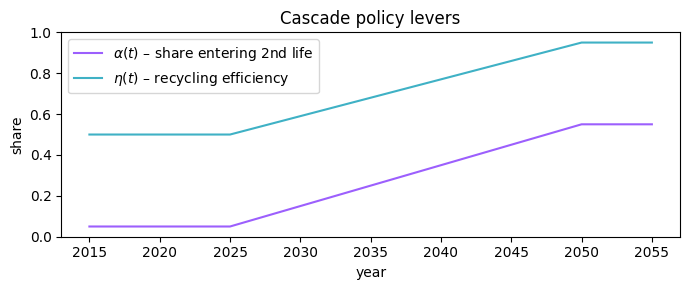

In [9]:
def linear_ramp(years, year_start, year_end, val_start, val_end):
    f = np.clip((years - year_start) / (year_end - year_start), 0, 1)
    return val_start + f * (val_end - val_start)

alpha_t = linear_ramp(years, 2025, 2050, ALPHA_2025, ALPHA_2050)
eta_t   = linear_ramp(years, 2025, 2050, ETA_2025,   ETA_2050)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(years, alpha_t, label=r"$\alpha(t)$ – share entering 2nd life", color="#9c5ffd")
ax.plot(years, eta_t,   label=r"$\eta(t)$ – recycling efficiency",      color="#3fb1c5")
ax.set(xlabel="year", ylabel="share", ylim=(0, 1), title="Cascade policy levers")
ax.legend()
fig.tight_layout()

### Solve the 2nd-life stock (cascade scenario)

We feed `α(t) × ev_outflow(t)` as the inflow into an `InflowDrivenDSM` with a
stationary-pack Weibull lifetime, and let flodym propagate it through the
cohort balance to give us the 2nd-life stock and 2nd-life outflow.

In [10]:
sl_inflow_cascade_v = ev_outflow_v * alpha_t
sl_inflow = StockArray(dims=dims, name="sl_inflow", values=sl_inflow_cascade_v)

sl_lifetime = WeibullLifetime(dims=dims)
sl_lifetime.set_prms(
    weibull_shape=np.full(dims.shape, SL_WEIBULL_SHAPE),
    weibull_scale=np.full(dims.shape, SL_WEIBULL_SCALE),
)

sl_dsm = InflowDrivenDSM(dims=dims, inflow=sl_inflow, lifetime_model=sl_lifetime)
sl_dsm.compute()

sl_stock_cascade_v   = sl_dsm.stock.values
sl_outflow_cascade_v = sl_dsm.outflow.values

### Recycling throughput and recovered material

In the **linear** scenario all retiring EV packs go directly to disposal and
nothing is recovered. In the **cascade** scenario, $(1-\alpha)$ of the retiring
EV outflow goes straight to recycling, the rest goes via the 2nd life and is
recycled when the stationary pack retires; the total throughput is multiplied
by $\eta(t)$ to give the recovered material.

In [11]:
# Linear baseline: no cascade flows
sl_inflow_linear_v        = np.zeros_like(years, dtype=float)
sl_stock_linear_v         = np.zeros_like(years, dtype=float)
sl_outflow_linear_v       = np.zeros_like(years, dtype=float)
recycling_throughput_linear_v = np.zeros_like(years, dtype=float)
recovered_linear_v        = np.zeros_like(years, dtype=float)

# Cascade: direct EV recycling fraction + delayed 2nd-life recycling
recycling_throughput_cascade_v = ev_outflow_v * (1 - alpha_t) + sl_outflow_cascade_v
recovered_cascade_v            = recycling_throughput_cascade_v * eta_t

### Visualising the cascade

Plotting the four time series together makes the lag structure visible: the
2nd-life stock peaks roughly a decade after the EV stock, and the recovered
material flow lags both — exactly the kind of timing structure that a
single-shot static LCA would miss.

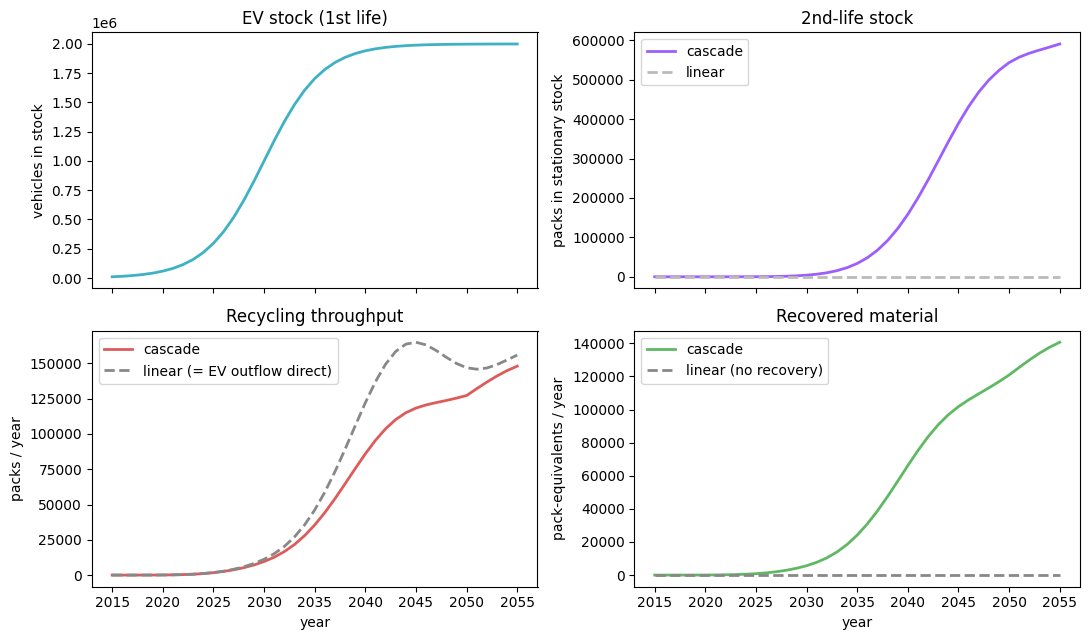

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex=True)

axes[0, 0].plot(years, ev_stock_v, color="#3fb1c5", lw=2)
axes[0, 0].set(ylabel="vehicles in stock", title="EV stock (1st life)")

axes[0, 1].plot(years, sl_stock_cascade_v, color="#9c5ffd", lw=2,
                label="cascade")
axes[0, 1].plot(years, sl_stock_linear_v,  color="#bbbbbb", lw=2, ls="--",
                label="linear")
axes[0, 1].set(ylabel="packs in stationary stock", title="2nd-life stock")
axes[0, 1].legend()

axes[1, 0].plot(years, recycling_throughput_cascade_v, color="#dd5b5b", lw=2,
                label="cascade")
axes[1, 0].plot(years, recycling_throughput_linear_v + ev_outflow_v,
                color="#888888", lw=2, ls="--",
                label="linear (= EV outflow direct)")
axes[1, 0].set(xlabel="year", ylabel="packs / year",
               title="Recycling throughput")
axes[1, 0].legend()

axes[1, 1].plot(years, recovered_cascade_v, color="#5fb963", lw=2,
                label="cascade")
axes[1, 1].plot(years, recovered_linear_v, color="#888888", lw=2, ls="--",
                label="linear (no recovery)")
axes[1, 1].set(xlabel="year", ylabel="pack-equivalents / year",
               title="Recovered material")
axes[1, 1].legend()

fig.tight_layout()

## From flodym to `TemporalDistribution`s

We scope the LCA to vehicles **produced** in `[ANALYSIS_START, ANALYSIS_END]`
and anchor the timeline at `FU_YEAR`. We need six temporal distributions:

| TD | Edge it lives on | Weights |
|------|------|------|
| `td_fleet_inflow`  | EV production       | $\propto$ EV inflow$(t)$ |
| `td_fleet_driving` | fleet electricity   | $\propto$ EV stock$(t)$ |
| `td_fleet_outflow` | EV end-of-life      | $\propto$ EV outflow$(t)$ |
| `td_repurposing`   | pack repurposing    | $\propto \alpha(t)\cdot\,$EV outflow$(t)$ |
| `td_sl_use`        | stationary use      | $\propto$ 2nd-life stock$(t)$ |
| `td_recycling`     | recycling credit    | $\propto$ recycling throughput$(t)$ |

Each TD is normalised to sum to 1; the actual physical magnitude lives in the
edge `amount` so that the temporal redistribution preserves mass.

> Note: previously we baked $\eta(t)$ into the recycling-credit TD by using
> "recovered material" as its weight. With the `bw_timex 1.0` foreground
> temporal evolution feature (next section) we keep $\eta(t)$ separate, on
> the `recycling_credit → battery` edge itself. The TD then carries only the
> *logistics* timing of pack arrivals at the recycler, and $\eta(t)$ carries
> the *efficiency* of the recycler at that moment — a much cleaner separation.

In [13]:
ANALYSIS_START = 2020
ANALYSIS_END   = 2050
FU_YEAR        = 2035

mask = (years >= ANALYSIS_START) & (years <= ANALYSIS_END)

years_window = years[mask]

inflow_window         = ev_inflow_v[mask]
stock_window          = ev_stock_v[mask]
outflow_window        = ev_outflow_v[mask]
sl_inflow_window      = sl_inflow_cascade_v[mask]
sl_stock_window       = sl_stock_cascade_v[mask]
recycling_window      = recycling_throughput_cascade_v[mask]
recovered_window      = recovered_cascade_v[mask]

# Totals — the magnitudes that the cascade edges scale to.
n_total_inflow         = inflow_window.sum()                # vehicles produced
n_total_outflow        = outflow_window.sum()               # vehicles retired
total_sl_inflow        = sl_inflow_window.sum()             # packs entering 2nd life
total_sl_pack_years    = sl_stock_window.sum()              # pack-years of stationary use
total_recycling        = recycling_window.sum()             # packs reaching recycling
total_recovered_packs  = recovered_window.sum()             # pack-equivalents recovered

print(f"Vehicles produced   {ANALYSIS_START}-{ANALYSIS_END}: {n_total_inflow:>14,.0f}")
print(f"Vehicles retired    {ANALYSIS_START}-{ANALYSIS_END}: {n_total_outflow:>14,.0f}")
print(f"Packs to 2nd life   {ANALYSIS_START}-{ANALYSIS_END}: {total_sl_inflow:>14,.0f}")
print(f"Pack-years stationary use:                       {total_sl_pack_years:>14,.0f}")
print(f"Total recycling throughput (packs):              {total_recycling:>14,.0f}")
print(f"Recovered material (pack-equivalents):           {total_recovered_packs:>14,.0f}")

Vehicles produced   2020-2050:      4,132,670
Vehicles retired    2020-2050:      2,176,165
Packs to 2nd life   2020-2050:        890,405
Pack-years stationary use:                            4,525,649
Total recycling throughput (packs):                   1,632,725
Recovered material (pack-equivalents):                1,346,927


In [14]:
from bw_temporalis import TemporalDistribution

offsets_years = (years_window - FU_YEAR).astype("int64")

def safe_normalize(v):
    s = v.sum()
    return v / s if s > 0 else np.full_like(v, 1.0 / len(v))

td_fleet_inflow = TemporalDistribution(
    date=offsets_years.astype("timedelta64[Y]"),
    amount=safe_normalize(inflow_window),
)
td_fleet_driving = TemporalDistribution(
    date=offsets_years.astype("timedelta64[Y]"),
    amount=safe_normalize(stock_window),
)
td_fleet_outflow = TemporalDistribution(
    date=offsets_years.astype("timedelta64[Y]"),
    amount=safe_normalize(outflow_window),
)
td_repurposing = TemporalDistribution(
    date=offsets_years.astype("timedelta64[Y]"),
    amount=safe_normalize(sl_inflow_window),
)
td_sl_use = TemporalDistribution(
    date=offsets_years.astype("timedelta64[Y]"),
    amount=safe_normalize(sl_stock_window),
)
td_recycling = TemporalDistribution(
    date=offsets_years.astype("timedelta64[Y]"),
    amount=safe_normalize(recycling_window),
)

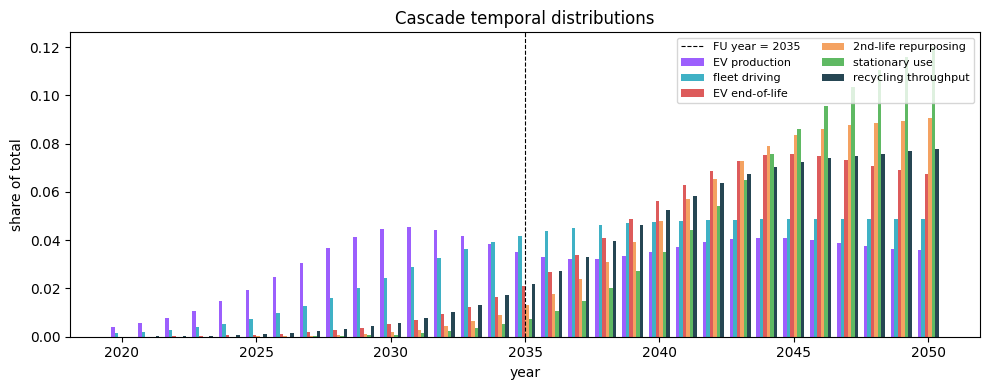

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
w = 0.13
ax.bar(years_window - 2.5*w, td_fleet_inflow.amount,  width=w, label="EV production",
       color="#9c5ffd")
ax.bar(years_window - 1.5*w, td_fleet_driving.amount, width=w, label="fleet driving",
       color="#3fb1c5")
ax.bar(years_window - 0.5*w, td_fleet_outflow.amount, width=w, label="EV end-of-life",
       color="#dd5b5b")
ax.bar(years_window + 0.5*w, td_repurposing.amount,   width=w, label="2nd-life repurposing",
       color="#f4a261")
ax.bar(years_window + 1.5*w, td_sl_use.amount,        width=w, label="stationary use",
       color="#5fb963")
ax.bar(years_window + 2.5*w, td_recycling.amount,     width=w, label="recycling throughput",
       color="#264653")
ax.axvline(FU_YEAR, color="k", ls="--", lw=0.8, label=f"FU year = {FU_YEAR}")
ax.set(xlabel="year", ylabel="share of total",
       title="Cascade temporal distributions")
ax.legend(loc="upper right", ncols=2, fontsize=8)
fig.tight_layout()

## Foreground LCA model

Two functional units that share the same intermediate processes:

```{mermaid}
flowchart LR
    glider(glider):::ei-->ev_production
    powertrain(powertrain):::ei-->ev_production
    battery(battery):::ei-->ev_production
    ev_production(ev production):::fg-->|inflow timing|linear_service
    ev_production-->|inflow timing|cascade_service
    electricity(electricity):::ei-->|fleet driving|linear_service
    electricity-->|fleet driving|cascade_service
    linear_service(linear service):::fg-->|outflow timing|used_ev
    cascade_service(cascade service):::fg-->|outflow timing|used_ev
    used_ev(used ev):::fg-->glider_eol(glider eol):::ei
    used_ev-->powertrain_eol(powertrain eol):::ei
    used_ev-->battery_eol(battery eol):::ei
    cascade_service-->|repurposing timing|pack_repurposing
    pack_repurposing(pack repurposing):::fg-->electricity
    cascade_service-->|stationary use|stationary_use
    stationary_use(stationary use):::fg-->electricity
    cascade_service-.->|"recycling timing<br/>(negative)"|recycling_credit
    recycling_credit(recycling credit):::fg-.->|"−1 kg/credit"|battery

    classDef ei color:#222832, fill:#3fb1c5, stroke:none;
    classDef fg color:#222832, fill:#9c5ffd, stroke:none;
```

The closed-loop substitution is implemented as a **negative** technosphere
edge from `recycling_credit` to background `battery`. Demanding a positive
amount of `recycling_credit` therefore subtracts the corresponding virgin
battery production from the cascade inventory.

In [16]:
if "foreground" in bd.databases:
    del bd.databases["foreground"]
foreground = bd.Database("foreground")
foreground.register()

In [17]:
# Per-vehicle production and end-of-life — same as the fleet notebook.
ev_production = foreground.new_node(
    "ev_production", name="production of an electric vehicle", unit="unit",
)
ev_production["reference product"] = "electric vehicle"
ev_production.save()
ev_production.new_edge(input=ev_production, amount=1, type="production").save()

glider_production    = background_2020.get(code="glider")
powertrain_production = background_2020.get(code="powertrain")
battery_production   = background_2020.get(code="battery")

glider_to_ev = ev_production.new_edge(
    input=glider_production, amount=MASS_GLIDER, type="technosphere",
)
powertrain_to_ev = ev_production.new_edge(
    input=powertrain_production, amount=MASS_POWERTRAIN, type="technosphere",
)
battery_to_ev = ev_production.new_edge(
    input=battery_production, amount=MASS_BATTERY, type="technosphere",
)

used_ev = foreground.new_node(
    "used_ev", name="used electric vehicle", unit="unit",
)
used_ev["reference product"] = "used electric vehicle"
used_ev.save()
used_ev.new_edge(input=used_ev, amount=-1, type="production").save()

glider_eol     = background_2020.get(name="glider_eol")
powertrain_eol = background_2020.get(name="powertrain_eol")
battery_eol    = background_2020.get(name="battery_eol")

used_ev_to_glider_eol     = used_ev.new_edge(input=glider_eol,     amount=-MASS_GLIDER,     type="technosphere")
used_ev_to_powertrain_eol = used_ev.new_edge(input=powertrain_eol, amount=-MASS_POWERTRAIN, type="technosphere")
used_ev_to_battery_eol    = used_ev.new_edge(input=battery_eol,    amount=-MASS_BATTERY,    type="technosphere")

### Cascade-only foreground processes

Three new intermediate processes carry the cascade structure:

- `pack_repurposing` consumes a small amount of electricity per pack to
  repurpose a used EV pack into a stationary unit.
- `stationary_use` represents one pack-year of stationary grid service and
  charges the loss-fraction electricity to the cascade.
- `recycling_credit` produces 1 unit of "avoided virgin battery" by feeding
  a `-1 kg` battery edge into the background. Demanding `R` units of this
  process subtracts the impact of `R` kg virgin battery production from the
  inventory, with the timing controlled by `td_recycling` and the magnitude
  scaled at each invocation date by the foreground evolution factors that
  encode $\eta(t)$ (see next section).

In [18]:
electricity_production = background_2020.get(name="electricity")

pack_repurposing = foreground.new_node(
    "pack_repurposing",
    name="repurposing of a used EV battery pack for stationary use",
    unit="pack",
)
pack_repurposing["reference product"] = "second-life pack"
pack_repurposing.save()
pack_repurposing.new_edge(input=pack_repurposing, amount=1, type="production").save()

repurposing_to_electricity = pack_repurposing.new_edge(
    input=electricity_production,
    amount=PACK_REPURPOSING_KWH_PER_KG * MASS_BATTERY,
    type="technosphere",
)
repurposing_to_electricity.save()

stationary_use = foreground.new_node(
    "stationary_use",
    name="stationary grid service per pack-year",
    unit="pack-year",
)
stationary_use["reference product"] = "stationary pack-year"
stationary_use.save()
stationary_use.new_edge(input=stationary_use, amount=1, type="production").save()

stationary_to_electricity = stationary_use.new_edge(
    input=electricity_production,
    amount=PACK_NOMINAL_KWH * ANNUAL_CYCLES_TIMES_DOD * LOSS_FRACTION,
    type="technosphere",
)
stationary_to_electricity.save()

recycling_credit = foreground.new_node(
    "recycling_credit",
    name="closed-loop recycling credit (per kg of recovered battery material)",
    unit="kg",
)
recycling_credit["reference product"] = "recycled battery equivalent"
recycling_credit.save()
recycling_credit.new_edge(input=recycling_credit, amount=1, type="production").save()

# Negative input = avoided virgin battery production.
recycling_to_battery = recycling_credit.new_edge(
    input=battery_production,
    amount=-1,
    type="technosphere",
)
recycling_to_battery.save()

### Functional units: `linear_service` and `cascade_service`

The two FUs share the EV-production / driving / disposal block. The cascade
service additionally pulls in the three cascade-only processes with the
appropriate fleet-level magnitudes.

In [19]:
linear_service = foreground.new_node(
    "linear_service",
    name="fleet driving service — linear scenario",
    unit="fleet-service",
)
linear_service["reference product"] = "fleet transport (linear)"
linear_service.save()
linear_service.new_edge(input=linear_service, amount=1, type="production").save()

linear_ev_to_service = linear_service.new_edge(
    input=ev_production, amount=n_total_inflow, type="technosphere",
)
linear_elec_to_service = linear_service.new_edge(
    input=electricity_production,
    amount=n_total_inflow * MILEAGE * ELECTRICITY_CONSUMPTION,
    type="technosphere",
)
linear_used_ev_to_service = linear_service.new_edge(
    input=used_ev, amount=-n_total_outflow, type="technosphere",
)

In [20]:
cascade_service = foreground.new_node(
    "cascade_service",
    name="fleet + grid service — cascade scenario",
    unit="fleet-service",
)
cascade_service["reference product"] = "fleet transport + grid service (cascade)"
cascade_service.save()
cascade_service.new_edge(input=cascade_service, amount=1, type="production").save()

# Same fleet block as linear.
cascade_ev_to_service = cascade_service.new_edge(
    input=ev_production, amount=n_total_inflow, type="technosphere",
)
cascade_elec_to_service = cascade_service.new_edge(
    input=electricity_production,
    amount=n_total_inflow * MILEAGE * ELECTRICITY_CONSUMPTION,
    type="technosphere",
)
cascade_used_ev_to_service = cascade_service.new_edge(
    input=used_ev, amount=-n_total_outflow, type="technosphere",
)

# Cascade-only edges.
cascade_repurposing_to_service = cascade_service.new_edge(
    input=pack_repurposing,
    amount=total_sl_inflow,
    type="technosphere",
)
cascade_stationary_to_service = cascade_service.new_edge(
    input=stationary_use,
    amount=total_sl_pack_years,
    type="technosphere",
)
# kg of battery material entering the recycler. The recycling_credit process
# internally credits -1 kg virgin battery per kg input, scaled at each
# invocation date by the foreground evolution factors that carry η(t).
cascade_recycling_to_service = cascade_service.new_edge(
    input=recycling_credit,
    amount=total_recycling * MASS_BATTERY,
    type="technosphere",
)

### Attach `TemporalDistribution`s to the relevant edges

We attach the same per-vehicle distributions as in the fleet notebook to the
sub-edges of `ev_production` and `used_ev`, the fleet-level distributions to
both service nodes, and the three cascade-specific distributions to the
cascade-only edges.

In [21]:
# Per-vehicle (component manufacturing / waste timing) — reused from fleet notebook.
td_glider_production = TemporalDistribution(
    date=np.array([-2, -1, 0], dtype="timedelta64[Y]"),
    amount=np.array([0.7, 0.1, 0.2]),
)
td_produce_powertrain_and_battery = TemporalDistribution(
    date=np.array([-1], dtype="timedelta64[Y]"),
    amount=np.array([1.0]),
)
td_treating_waste = TemporalDistribution(
    date=np.array([3], dtype="timedelta64[M]"),
    amount=np.array([1.0]),
)

In [22]:
# Per-vehicle timing inside ev_production / used_ev.
glider_to_ev["temporal_distribution"] = td_glider_production; glider_to_ev.save()
powertrain_to_ev["temporal_distribution"] = td_produce_powertrain_and_battery; powertrain_to_ev.save()
battery_to_ev["temporal_distribution"]    = td_produce_powertrain_and_battery; battery_to_ev.save()

used_ev_to_glider_eol["temporal_distribution"]     = td_treating_waste; used_ev_to_glider_eol.save()
used_ev_to_powertrain_eol["temporal_distribution"] = td_treating_waste; used_ev_to_powertrain_eol.save()
used_ev_to_battery_eol["temporal_distribution"]    = td_treating_waste; used_ev_to_battery_eol.save()

# Linear service: the three fleet-level TDs.
linear_ev_to_service["temporal_distribution"]      = td_fleet_inflow;  linear_ev_to_service.save()
linear_elec_to_service["temporal_distribution"]    = td_fleet_driving; linear_elec_to_service.save()
linear_used_ev_to_service["temporal_distribution"] = td_fleet_outflow; linear_used_ev_to_service.save()

# Cascade service: same three for the fleet block + three cascade-specific.
cascade_ev_to_service["temporal_distribution"]          = td_fleet_inflow;  cascade_ev_to_service.save()
cascade_elec_to_service["temporal_distribution"]        = td_fleet_driving; cascade_elec_to_service.save()
cascade_used_ev_to_service["temporal_distribution"]     = td_fleet_outflow; cascade_used_ev_to_service.save()
cascade_repurposing_to_service["temporal_distribution"] = td_repurposing;   cascade_repurposing_to_service.save()
cascade_stationary_to_service["temporal_distribution"]  = td_sl_use;        cascade_stationary_to_service.save()
cascade_recycling_to_service["temporal_distribution"]   = td_recycling;     cascade_recycling_to_service.save()

### Foreground evolution: $\eta(t)$ and EV efficiency improvement

`bw_timex>=1.0` lets a foreground exchange's amount evolve over time
independently of its `TemporalDistribution`. We attach a
`temporal_evolution_factors` dict whose keys are dates and whose values are
multiplicative factors on the base exchange amount; `bw_timex` linearly
interpolates between specified dates and clamps outside the range.

We use this in two places:

1. **Recycling efficiency $\eta(t)$** on the `recycling_credit → battery`
   edge: 50% in 2025 ramping to 95% in 2050. The base edge amount is
   $-1$ kg of virgin battery per kg of recycled material; the foreground
   evolution scales this so that early-cohort recycling avoids less
   virgin production than late-cohort recycling.
2. **EV electricity-consumption efficiency** on both the `linear_service`
   and `cascade_service` driving-electricity edges: 100% in 2020 falling
   to 70% in 2050 (a stand-in for vehicle efficiency learning).

Without foreground evolution we would need to bake these factors into the
edge amounts and TDs, which couples policy levers ($\eta$) to logistics
parameters (recycling throughput timing) and makes scenario sweeps awkward.
With foreground evolution, swapping a lever is a one-line dictionary edit
on the relevant exchange.

In [23]:
from datetime import datetime as _dt

# η(t): recycling efficiency ramps from 50% (2025) to 95% (2050).
recycling_to_battery["temporal_evolution_factors"] = {
    _dt(2025, 1, 1): ETA_2025,
    _dt(2050, 1, 1): ETA_2050,
}
recycling_to_battery.save()

# EV efficiency: kWh/km ratio falls from 1.0 (2020) to 0.7 (2050).
EV_EFFICIENCY_2020 = 1.0
EV_EFFICIENCY_2050 = 0.7
ev_efficiency_factors = {
    _dt(2020, 1, 1): EV_EFFICIENCY_2020,
    _dt(2050, 1, 1): EV_EFFICIENCY_2050,
}
linear_elec_to_service["temporal_evolution_factors"]  = ev_efficiency_factors
linear_elec_to_service.save()
cascade_elec_to_service["temporal_evolution_factors"] = ev_efficiency_factors
cascade_elec_to_service.save()

In [24]:
for db in bd.databases:
    bd.Database(db).process()

In [25]:
bd.Method(("GWP", "example")).write([(("biosphere", "CO2"), 1)])

## Time-explicit LCA: linear vs cascade

We instantiate one `TimexLCA` per scenario, both anchored at `FU_YEAR`. Each
gets its own `build_timeline` so that the scenario-specific cascade edges are
correctly resolved.

In [26]:
from datetime import datetime
from bw_timex import TimexLCA

method = ("GWP", "example")

database_dates = {
    "background_2020": datetime.strptime("2020", "%Y"),
    "background_2030": datetime.strptime("2030", "%Y"),
    "background_2040": datetime.strptime("2040", "%Y"),
    "foreground": "dynamic",
}

linear_service_node  = bd.get_node(database="foreground", code="linear_service")
cascade_service_node = bd.get_node(database="foreground", code="cascade_service")

In [27]:
tlca_linear = TimexLCA({linear_service_node: 1}, method, database_dates)
tlca_linear.build_timeline(starting_datetime=datetime(FU_YEAR, 1, 1), temporal_grouping="year")
tlca_linear.lci()
tlca_linear.static_lcia()

tlca_cascade = TimexLCA({cascade_service_node: 1}, method, database_dates)
tlca_cascade.build_timeline(starting_datetime=datetime(FU_YEAR, 1, 1), temporal_grouping="year")
tlca_cascade.lci()
tlca_cascade.static_lcia()

print(f"Linear   time-explicit GWP: {tlca_linear.static_score:>16,.0f} kg CO2-eq")
print(f"Cascade  time-explicit GWP: {tlca_cascade.static_score:>16,.0f} kg CO2-eq")
print(f"Cascade − linear (Δ):        {tlca_cascade.static_score - tlca_linear.static_score:>16,.0f} kg CO2-eq")
print(f"Relative change:              {100 * (tlca_cascade.static_score - tlca_linear.static_score) / tlca_linear.static_score:>15.1f} %")

2026-05-02 15:27:24.528 | INFO     | bw_timex.timex_lca:__init__:122 - Initializing TimexLCA object...


2026-05-02 15:27:24.529 | INFO     | bw_timex.timex_lca:__init__:139 - Calculating base LCA...


2026-05-02 15:27:24.549 | INFO     | bw_timex.timex_lca:__init__:156 - Collecting node infos...


2026-05-02 15:27:24.563 | INFO     | bw_timex.timex_lca:build_timeline:252 - No edge filter function provided. Skipping all edges in background databases.


2026-05-02 15:27:24.565 | INFO     | bw_timex.timex_lca:build_timeline:268 - Creating activity time mapping...


...

2026-05-02 15:27:26.765 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:560 - Reference date 2050-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


2026-05-02 15:27:26.765 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:560 - Reference date 2050-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


2026-05-02 15:27:26.788 | INFO     | bw_timex.timex_lca:lci:385 - Expanding matrices...


2026-05-02 15:27:27.887 | INFO     | bw_timex.timex_lca:lci:404 - Calculating dynamic inventory...


Linear   time-explicit GWP:   37,315,183,841 kg CO2-eq
Cascade  time-explicit GWP:   36,219,072,859 kg CO2-eq
Cascade − linear (Δ):          -1,096,110,982 kg CO2-eq
Relative change:                         -2.9 %


The cascade scenario adds a (small) operational burden from second-life
operation and a much larger negative contribution from the recycling credit:
the net effect should be a measurable reduction in fleet GWP. By construction
the result depends on the assumed `α(t)` and `η(t)` ramps and on the toy
"battery" emission factors — so the magnitudes here are illustrative.

### Dynamic characterisation

We characterise the dynamic inventory under GWP100 (fixed-time-horizon) for
both scenarios using the IPCC AR6 CO₂ characterisation function from
`dynamic_characterization`.

In [28]:
from dynamic_characterization.ipcc_ar6.radiative_forcing import characterize_co2

characterization_functions = {
    bd.get_node(code="CO2").id: characterize_co2,
}

tlca_linear.dynamic_lcia(
    metric="GWP",
    fixed_time_horizon=False,
    time_horizon=100,
    characterization_functions=characterization_functions,
)
tlca_cascade.dynamic_lcia(
    metric="GWP",
    fixed_time_horizon=False,
    time_horizon=100,
    characterization_functions=characterization_functions,
)
print(f"Linear  dynamic GWP100:  {tlca_linear.dynamic_score:>16,.0f} kg CO2-eq")
print(f"Cascade dynamic GWP100:  {tlca_cascade.dynamic_score:>16,.0f} kg CO2-eq")

Linear  dynamic GWP100:    37,315,183,841 kg CO2-eq
Cascade dynamic GWP100:    36,219,072,859 kg CO2-eq


### Policy-lever sweep: does the timing of $\eta(t)$ matter?

To show the value of having $\eta(t)$ as a foreground evolution rather than
baked into the edge amount, we rerun the cascade scenario under two extreme
$\eta(t)$ profiles — frozen at today's 50% and immediate jump to the
2050-target 95% — without touching anything else in the model. Each rerun is
just a one-line dictionary update on the `recycling_credit → battery` edge
followed by `bd.Database("foreground").process()`.

In [29]:
def rerun_cascade_with_eta(factors_dict, label):
    recycling_to_battery["temporal_evolution_factors"] = factors_dict
    recycling_to_battery.save()
    bd.Database("foreground").process()

    tlca = TimexLCA({cascade_service_node: 1}, method, database_dates)
    tlca.build_timeline(starting_datetime=datetime(FU_YEAR, 1, 1), temporal_grouping="year")
    tlca.lci()
    tlca.static_lcia()
    tlca.dynamic_lcia(
        metric="GWP",
        fixed_time_horizon=False,
        time_horizon=100,
        characterization_functions=characterization_functions,
    )
    print(f"{label:36s} static={tlca.static_score:>16,.0f}  dynamic={tlca.dynamic_score:>16,.0f}")
    return tlca

print(f"{'cascade (η ramp 50% → 95%)':36s} static={tlca_cascade.static_score:>16,.0f}  dynamic={tlca_cascade.dynamic_score:>16,.0f}")
tlca_cascade_frozen_low  = rerun_cascade_with_eta(
    {datetime(2025, 1, 1): 0.50, datetime(2050, 1, 1): 0.50},
    "cascade (η frozen at 50%)",
)
tlca_cascade_frozen_high = rerun_cascade_with_eta(
    {datetime(2025, 1, 1): 0.95, datetime(2050, 1, 1): 0.95},
    "cascade (η frozen at 95%)",
)

# Restore the original η ramp so subsequent cells use the headline scenario.
recycling_to_battery["temporal_evolution_factors"] = {
    datetime(2025, 1, 1): ETA_2025,
    datetime(2050, 1, 1): ETA_2050,
}
recycling_to_battery.save()
bd.Database("foreground").process()

cascade (η ramp 50% → 95%)           static=  36,219,072,859  dynamic=  36,219,072,859


2026-05-02 15:27:30.038 | INFO     | bw_timex.timex_lca:__init__:122 - Initializing TimexLCA object...


2026-05-02 15:27:30.039 | INFO     | bw_timex.timex_lca:__init__:139 - Calculating base LCA...


2026-05-02 15:27:30.057 | INFO     | bw_timex.timex_lca:__init__:156 - Collecting node infos...


2026-05-02 15:27:30.073 | INFO     | bw_timex.timex_lca:build_timeline:252 - No edge filter function provided. Skipping all edges in background databases.


...

2026-05-02 15:27:33.745 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:560 - Reference date 2050-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


2026-05-02 15:27:33.746 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:560 - Reference date 2050-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


2026-05-02 15:27:33.767 | INFO     | bw_timex.timex_lca:lci:385 - Expanding matrices...


2026-05-02 15:27:34.920 | INFO     | bw_timex.timex_lca:lci:404 - Calculating dynamic inventory...


cascade (η frozen at 95%)            static=  35,973,294,427  dynamic=  35,973,294,427


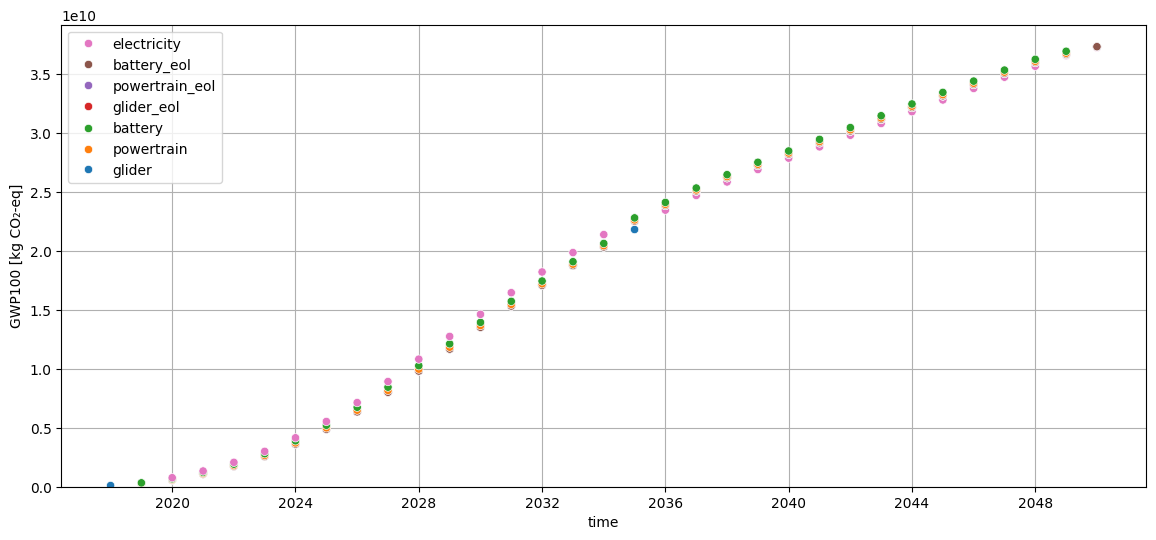

In [30]:
tlca_linear.plot_dynamic_characterized_inventory(sum_emissions_within_activity=True, cumsum=True)

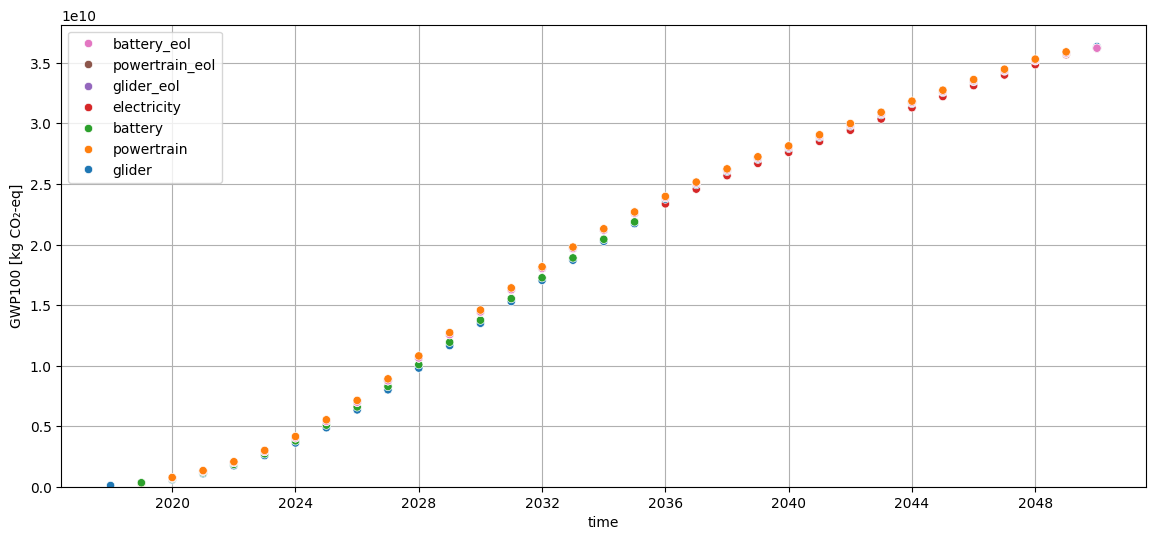

In [31]:
tlca_cascade.plot_dynamic_characterized_inventory(sum_emissions_within_activity=True, cumsum=True)

### Side-by-side scenario comparison

Aggregating both characterised inventories on a common time axis lets us see
the climate value of the cascade as a *flow* rather than a single number: the
recycling credit appears as a drop in cumulative GWP from the year that the
recovered material starts to come back.

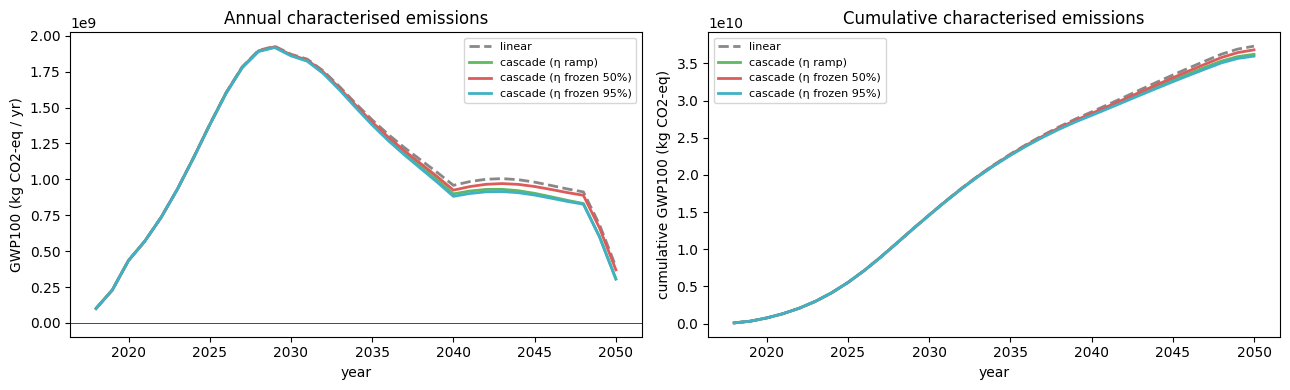

In [32]:
def aggregate_yearly(tlca):
    df = tlca.characterized_inventory.copy()
    df["year"] = pd.to_datetime(df["date"]).dt.year
    return df.groupby("year")["amount"].sum().sort_index()

scenarios = {
    "linear":                  (tlca_linear,             "#888888", "--"),
    "cascade (η ramp)":        (tlca_cascade,            "#5fb963", "-"),
    "cascade (η frozen 50%)":  (tlca_cascade_frozen_low, "#dd5b5b", "-"),
    "cascade (η frozen 95%)":  (tlca_cascade_frozen_high,"#3fb1c5", "-"),
}

aggs = {label: aggregate_yearly(tl) for label, (tl, _, _) in scenarios.items()}
all_years = sorted(set().union(*[a.index for a in aggs.values()]))
aggs = {label: a.reindex(all_years, fill_value=0.0) for label, a in aggs.items()}
cums = {label: a.cumsum() for label, a in aggs.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for label, (_, color, ls) in scenarios.items():
    axes[0].plot(all_years, aggs[label], color=color, lw=2, ls=ls, label=label)
    axes[1].plot(all_years, cums[label], color=color, lw=2, ls=ls, label=label)

axes[0].axhline(0, color="k", lw=0.5)
axes[0].set(xlabel="year", ylabel="GWP100 (kg CO2-eq / yr)",
            title="Annual characterised emissions")
axes[0].legend(fontsize=8)

axes[1].set(xlabel="year", ylabel="cumulative GWP100 (kg CO2-eq)",
            title="Cumulative characterised emissions")
axes[1].legend(fontsize=8)

fig.tight_layout()

## Wrap-up

Three observations matter more than the specific numbers above:

1. **Coupled cohorts only fall out of dMFA + time-explicit LCA together.**
   The 2nd-life stock and the recycled-material flow lag the EV outflow by
   different amounts; in the cascade scenario the recycling credit therefore
   has a substantially later temporal distribution than the production
   burden it offsets, and the climate value depends on the *gap* between the
   two.
2. **Foreground evolution turns parameters into policy levers.** By keeping
   $\eta(t)$ as `temporal_evolution_factors` on the `recycling_credit →
   battery` edge — rather than baking it into the cascade-edge amount — we
   were able to sweep three $\eta$ trajectories with a one-line dictionary
   edit each. The same machinery applies to the EV efficiency improvement we
   layered on the driving-electricity edge.
3. **Toy chemistries hide most of the policy story.** Replacing the single
   `battery` background process with chemistry-resolved cell, cathode and
   recycling inventories (e.g. NMC811 vs LFP, hydromet vs pyromet) is the
   minimum needed to address the EU Battery Regulation Art. 8 recycled-content
   feasibility question.

The structural skeleton — three coupled stocks, six TDs, two FUs and two
foreground evolutions — is fully reusable for a real research application.
From here the natural extensions are

- splitting `battery` into two cell chemistries with their own production /
  recycling inventories, each with chemistry-specific $\eta(t)$ as foreground
  evolution;
- wiring `premise` scenarios into the background databases for an explicit
  grid-decarbonisation pathway;
- replacing the static GWP100 with `GWP*` / `AGTP` to expose the climate
  value of *delayed* virgin substitution.